In [1]:
import warnings; warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc
from binance import Client

In [2]:
client = Client()
def get_tickers():
    tickers = []
    for info in client.futures_mark_price():
        ticker = info['symbol']
        if ticker[-4:] == "USDT":
            tickers.append(info['symbol'])
    return tickers

def get_sample(ticker, start_date="1 Jan, 2021"):
    klines = np.array(client.futures_historical_klines(ticker, Client.KLINE_INTERVAL_1DAY, start_date))
    sample = pd.DataFrame(klines.reshape(-1, 12), dtype=float, columns=['datetime',
                                                                        'open', 
                                                                        'high', 
                                                                        'low', 
                                                                        'close', 
                                                                        'volume', 
                                                                        'close time', 
                                                                        'quote asset volume, number of trades', 
                                                                        'number of trades',
                                                                        'taker buy base asset volume', 
                                                                        'taker buy quote asset volume', 
                                                                        'ignore'])
    sample['datetime'] = pd.to_datetime(sample['datetime'], unit='ms')
    sample.set_index('datetime', inplace=True)
    sample = sample[['open', 'high', 'low', 'close', 'volume']].copy()
    return sample

In [3]:
tickers = get_tickers()

# drop coins with length < 200
for ticker in tickers:
    sample = get_sample(ticker, start_date="1 Mar, 2021")
    if len(sample) < 200: tickers.remove(ticker)
    else: continue

In [4]:
# define preprocessing functions
def add_momentum(sample, period=20):
    df = sample.copy()
    df[f'mom{period}'] = (df['close'] - df.shift(period)['close'])/df.shift(period)['close']
    sample[f'mom{period}'] = df[f'mom{period}']; del df
    return sample

def add_noise(sample, period=20):
    df = sample.copy()
    df['noise'] = 1. - abs(df['close'] - df['open'])/(df['high'] - df['low'])
    df[f'noise{period}'] = df['noise'].rolling(period).mean()
    sample[f'noise{period}'] = df[f"noise{period}"]; del df
    return sample

def add_percentB(sample, period=20):
    df = sample.copy()
    df['center'] = df['close'].rolling(period).mean()
    df['upper'] = df['center'] + 2.*df['close'].rolling(period).std()
    df['lower'] = df['center'] - 2.*df['close'].rolling(period).std()
    df['percentB'] = (df['close'] - df['lower'])/(df['upper'] - df['lower'])
    sample['percentB'] = df['percentB']; del df
    return sample

def add_retarded_reward(sample, gamma=0.95):
    df = sample.copy()
    df['log_reward'] = np.log(df['reward'])
    for idx in df.index:
        if idx == df.index[0]:
            df.loc[idx, 'retarded_reward'] = df.loc[idx, 'log_reward']
            continue
        df.loc[idx, 'retarded_reward'] = df.loc[idx, 'log_reward'] + gamma*df.shift(1).loc[idx, 'retarded_reward']
    sample['retarded_reward'] = df['retarded_reward']; del df
    return sample

def add_RSI(sample, period=14):
    df = sample.copy()
    df['TP'] = (df['high'] + df['low'] + df['close'])/3.
    df['U'] = 0.; df['D'] = 0.
    for idx in df.index:
        if df.shift(1).loc[idx, 'TP'] < df.loc[idx, 'TP']:
            df.loc[idx, 'U'] = df.loc[idx, 'TP']
        else:
            df.loc[idx, 'D'] = df.loc[idx, 'TP']
    df['AU'] = df['U'].rolling(period).mean()
    df['AD'] = df['D'].rolling(period).mean()
    df['RSI'] = df['AU']/(df['AU']+df['AD'])
    sample['TP'] = df['TP']
    sample['RSI'] = df['RSI']; del df
    return sample

In [40]:
# Test will be based on different days of momentum
samples = dict()
for ticker in tickers:
    sample = get_sample(ticker, start_date="1 Apr, 2021")   # at least 21 coins are possible
    
    # preprocess
    sample['number'] = sample.index.map(mdates.date2num)
    sample['reward'] = 1. + sample['close'].pct_change()
    sample['total_reward'] = sample['reward'].cumprod()
    sample.dropna(inplace=True)
    sample = add_momentum(sample, period=7)
    sample = add_momentum(sample, period=20)
    sample = add_RSI(sample)
    sample = add_noise(sample, period=15)
    sample = add_retarded_reward(sample)
    sample['ema7'] = sample['close'].ewm(7).mean()
    sample['ema20'] = sample['close'].ewm(20).mean()
    sample['ema30'] = sample['close'].ewm(30).mean()
    sample['ema40'] = sample['close'].ewm(40).mean()
    sample['ema50'] = sample['close'].ewm(50).mean()
    sample.dropna(inplace=True)
    
    samples[ticker] = sample.copy(); del sample
    
btc = samples['BTCUSDT'].copy()
eth = samples['ETHUSDT'].copy()

(array([  1.,   1.,   1.,   9.,  26.,  66., 165., 203.,  75.,  21.,  10.,
          4.,   3.,   1.,   1.,   1.,   1.,   1.]),
 array([-0.34362781, -0.29445951, -0.24529121, -0.19612291, -0.14695461,
        -0.09778631, -0.04861801,  0.00055028,  0.04971858,  0.09888688,
         0.14805518,  0.19722348,  0.24639178,  0.29556007,  0.34472837,
         0.39389667,  0.44306497,  0.49223327,  0.54140157]),
 <BarContainer object of 18 artists>)

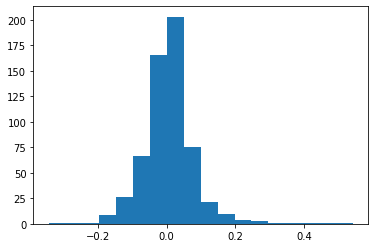

In [52]:
# Random walk theory?
sample = get_sample("WAVESUSDT", start_date="1 Jan, 2019")
returns = []
for idx in sample.index:
    if idx == sample.index[0]:
        continue
    
    returns.append(sample.loc[idx, 'close']/sample.shift(1).loc[idx, 'close'] - 1.)

plt.hist(returns, bins=18)

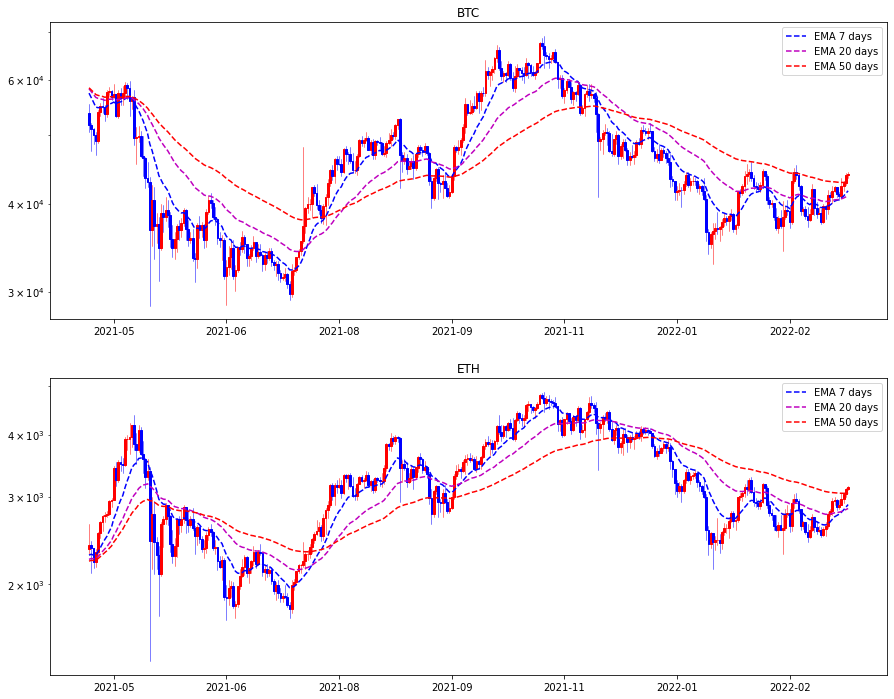

In [6]:
plt.figure(figsize=(15, 12))
p1 = plt.subplot(2, 1, 1)
plt.title("BTC")
plt.yscale("log")
ohlc = btc[['number', 'open', 'high', 'low', 'close']]
candlestick_ohlc(p1, ohlc.values, width=.8, colorup='red', colordown='blue')
p1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.plot(btc.number, btc.ema7, 'b--', label="EMA 7 days")
plt.plot(btc.number, btc.ema20, 'm--', label="EMA 20 days")
plt.plot(btc.number, btc.ema50, 'r--', label='EMA 50 days')

plt.legend(loc='best')

p2 = plt.subplot(2, 1, 2)
plt.title("ETH")
plt.yscale("log")
ohlc = eth[['number', 'open', 'high', 'low', 'close']]
candlestick_ohlc(p2, ohlc.values, width=.8, colorup='red', colordown='blue')
p2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.plot(eth.number, eth.ema7, 'b--', label="EMA 7 days")
plt.plot(eth.number, eth.ema20, 'm--', label="EMA 20 days")
plt.plot(eth.number, eth.ema50, 'r--', label='EMA 50 days')
plt.legend(loc='best')

plt.show()

In [29]:
# 1. choose top 21 trading coins
# 2. sort in indicator
# 3. compare top 5 / bottom 5 momentum coins
def inspect_indicator(indicator, market_timing=False, idv_timing=False, filtering=False):
    book = samples['BTCUSDT'][['close']].copy()
    book['number'] = book.index.map(mdates.date2num)
    book['reward'] = 1. 
    book['total_reward'] = 1.

    for idx in book.index[:-1]:
        # select 21 highest volume coins
        volumes = dict()
        for ticker in tickers:
            try:
                if filtering and samples[ticker].loc[idx, 'noise15'] > 0.7:
                    continue
                volumes[ticker] = samples[ticker].loc[idx, 'TP']*samples[ticker].loc[idx, 'volume']
            except:
                continue
        top21v = dict(sorted(volumes.items(), key=(lambda x: x[1]), reverse=True)[:21])
    
        # sort in indicator order
        temp = dict()
        for ticker in top21v.keys():
            try:
                temp[ticker] = samples[ticker].loc[idx, indicator]
            except:
                print(ticker)
        temp = dict(sorted(temp.items(), key=(lambda x: x[1]), reverse=True))
    
        # estimate reward for top/bottom 5
        reward_up = 0.
        for coin in list(temp.keys())[:4]:
            lev = 0
            close = samples[coin].loc[idx, 'close']
            close_m1 = samples[coin].shift(1).loc[idx, 'close']
            if samples[coin].loc[idx, 'mom7'] > 0.: lev += 1
            if samples[coin].loc[idx, 'mom20'] > 0.: lev += 1
                
            if idv_timing:
                #if samples[coin].loc[idx, 'close'] < samples[coin].loc[idx, 'ema7']: lev -= 1
                #if samples[coin].loc[idx, 'close'] < samples[coin].loc[idx, 'ema20']: lev -= 1
                if close > close_m1: lev -= 1
                
            this_reward = lev*(samples[coin].shift(-1).loc[idx, 'reward'] - 1.003)
            reward_up += (1/4)*(1.+this_reward)
            
        reward_down = 0.
        for coin in list(temp.keys())[-8:]:
            lev = 0
            close = samples[coin].loc[idx, 'close']
            close_m1 = samples[coin].shift(1).loc[idx, 'close']
            if samples[coin].loc[idx, 'ema7'] > samples[coin].loc[idx, 'close']: lev -= 1
            if samples[coin].loc[idx, 'ema20'] > samples[coin].loc[idx, 'close']: lev -= 1
            
            if idv_timing:
                if close < close_m1: lev += 1
            
            this_reward = lev*(samples[coin].shift(-1).loc[idx, 'reward'] - 1.003)
            reward_down += (1/8)*(1.+this_reward)

        if (btc.loc[idx, 'close'] < btc.loc[idx, 'ema50'] or eth.loc[idx, 'close'] < eth.loc[idx, 'ema50']):
            reward = reward_down
        else:
            reward = reward_up
        #if market_timing and (btc.loc[idx, 'close'] < btc.loc[idx, 'ema50'] or eth.loc[idx, 'close'] < eth.loc[idx, 'ema50']):
        #    reward = 1.
        #else:
        #    reward = reward_up
        #is_bull = btc.loc[idx, 'high'] > btc.shift(1).loc[idx, 'high'] and eth.loc[idx, 'high'] > eth.shift(1).loc[idx, 'high']
        #if is_bull:
        #    reward = reward_up
        #else:
        #    reward = reward_down
            
            
        book.loc[idx, 'reward'] = reward
  
    total_reward = 1.
    for idx in book.index:
        total_reward *= book.loc[idx, 'reward']
        book.loc[idx, 'total_reward'] = total_reward
    
    return book

In [30]:
def evaluate(book, title=""):
    # CAGR, MDD, Volatility, Sharpe
    CAGR = book['total_reward'].iloc[-1]**(365/len(book.index)) - 1.

    historical_max = book['total_reward'].cummax()
    daily_drawdown = book['total_reward']/historical_max - 1.
    historical_dd = daily_drawdown.cummin()
    MDD = historical_dd.min()
    
    VOL = np.std(book['reward'])*np.sqrt(365.)
    Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.))

    # win-loose ratio
    win = 0; loose = 0
    for idx in book.index:
        if book.loc[idx, 'reward'] == 1:
            continue
        elif book.loc[idx, 'reward'] > 1.:
            win += 1
        else:
            loose += 1
    win_loose_ratio = win/(win+loose)

    print(f"==== {title} ====")
    print(f"Accumulated Returns: {(book['total_reward'].iloc[-1]-1.)*100:.2f}%")
    print(f"CAGR: {CAGR*100:.2f}%")
    print(f"MDD: {MDD*100:.2f}%")
    print(f"VOL: {VOL*100:.2f}%")
    print(f"Sharpe: {Sharpe*100:.2f}%")
    print(f"win-loose ratio: {win_loose_ratio*100:.2f}%")
    print()

In [31]:
mom7 = inspect_indicator("mom7", market_timing=False, idv_timing=False, filtering=True)
evaluate(mom7, "momentum 7 days")

mom7_mt = inspect_indicator("mom7", market_timing=True, idv_timing=True, filtering=True)
evaluate(mom7_mt, "momentum 7 days with market timing")

mom20 = inspect_indicator("mom20", market_timing=False, idv_timing=False, filtering=True)
evaluate(mom20, "momentum 20 days")

mom20_mt = inspect_indicator("mom20", market_timing=True, idv_timing=True, filtering=False)
evaluate(mom20_mt, "momentum 20 days with market timing")

==== momentum 7 days ====
Accumulated Returns: 414.83%
CAGR: 486.83%
MDD: -80.49%
VOL: 274.73%
Sharpe: 13486.00%
win-loose ratio: 51.04%

==== momentum 7 days with market timing ====
Accumulated Returns: 1880.33%
CAGR: 2413.76%
MDD: -56.38%
VOL: 180.81%
Sharpe: 20450.69%
win-loose ratio: 54.90%

==== momentum 20 days ====
Accumulated Returns: 1060.21%
CAGR: 1311.15%
MDD: -69.08%
VOL: 251.39%
Sharpe: 14751.28%
win-loose ratio: 51.93%

==== momentum 20 days with market timing ====
Accumulated Returns: 1301.50%
CAGR: 1630.56%
MDD: -45.50%
VOL: 169.13%
Sharpe: 21831.88%
win-loose ratio: 52.52%



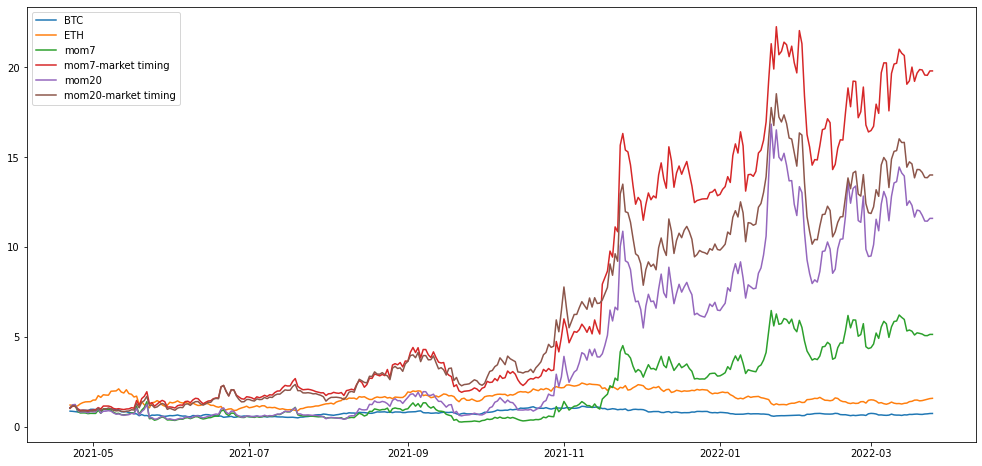

In [32]:
plt.figure(figsize=(17, 8))
#plt.yscale('log')
plt.plot(btc.index, btc.total_reward, label="BTC")
plt.plot(eth.index, eth.total_reward, label="ETH")
plt.plot(mom7.index, mom7.total_reward, label="mom7")
plt.plot(mom7_mt.index, mom7_mt.total_reward, label="mom7-market timing")
plt.plot(mom20.index, mom20.total_reward, label="mom20")
plt.plot(mom20_mt.index, mom20_mt.total_reward, label="mom20-market timing")
plt.legend(loc='best')

plt.show()